In [1]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import property_driven_ml.logics as logics
import property_driven_ml.training as training

from withProperties.attack_ import (
    DoSHttpFloodPostcondition,
    TabularRuleConstraint,
    PortscanPostcondition,
    GlobalBounds
)
from sklearn.model_selection import train_test_split
from utils.utils import *
from sklearn.preprocessing import MinMaxScaler
from utils.models import build_model
from specs import ATTACK_SPECS
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
TARGET_LABELS = ["BENIGN", "ATTACK"]
ATTACK_SOURCE_LABELS = ["DOS_HTTP_FLOOD", "PORTSCAN"]
PROPERTY_MODEL_FEATURES = MODEL_NUMERIC_FEATURES + ENGINEERED_FEATURES
FEATURE_COLS = PROPERTY_MODEL_FEATURES

label_to_idx = {label: i for i, label in enumerate(TARGET_LABELS)}
idx = {name: i for i, name in enumerate(FEATURE_COLS)}

BOOLEAN_FEATURES = ["valid_tcp_handshake", "valid_http_conn"]
FROZEN_FEATURES = [
    "valid_tcp_handshake",
    "valid_http_conn"
]

FROZEN_IDXS = [idx[f] for f in FROZEN_FEATURES if f in idx]

BATCH_SIZE = 1024
RANDOM_STATE = 42
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

LAMBDA_DOS = 20.0
LAMBDA_SCAN = 1
PGD_STEPS = 10
PGD_RESTARTS = 1
PGD_STEP_SIZE = 0.01
PATIENCE = 5
MIN_DELTA = 1e-4

In [3]:
def make_binary_attack_df(
    df: pd.DataFrame,
    attack_labels: list[str] = ["DOS_HTTP_FLOOD", "PORTSCAN"],
) -> pd.DataFrame:
    df = df[df["label"].isin(["BENIGN"] + attack_labels)].copy()
    df["attack_type"] = df["label"]
    df["label"] = np.where(df["label"] == "BENIGN", "BENIGN", "ATTACK")
    df["label_id"] = df["label"].map({"BENIGN": 0, "ATTACK": 1})
    return df

In [4]:
raw_train_df = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_cicids2017 = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
dataset_name = "CICIoT2023"
print(raw_train_df)

train_full_df = make_binary_attack_df(
    raw_train_df,
    attack_labels=ATTACK_SOURCE_LABELS,
)

print("Training set label distribution before split:")
print_label_distribution(train_full_df)

train_val_df, test_df = train_test_split(
    train_full_df,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=train_full_df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_val_df["label"],
)

                   ts                 uid                  id.orig_h  \
0        1.660668e+09  Ch3ncG1kMRNM7V7Bz8             192.168.137.17   
1        1.660671e+09  CGoYkg1Yv95df4aHR5            192.168.137.178   
2        1.660680e+09  CBMKGc4I6qc5R9ZlAj            192.168.137.109   
3        1.664870e+09  CL1qy43yrQxloFa1Ze             192.168.137.41   
4        1.660680e+09  CS3uF51AyiZ2Qng7xk             192.168.137.15   
...               ...                 ...                        ...   
2922692  1.665263e+09  Ct7pfv3x32wzezGTY9  fe80::ea1b:69ff:fef8:d6e6   
2922693  1.665263e+09  CTx2a14SfJoHvctCWb  fe80::ea1b:69ff:fef8:d6e6   
2922694  1.665264e+09  CvsxK23jNjRXUhJHM3  fe80::ea1b:69ff:fef8:d6e6   
2922695  1.665264e+09   CvSVOTt5PvkZvZN5h  fe80::ea1b:69ff:fef8:d6e6   
2922696  1.661974e+09  CIVnGJ3u0JyzJWSdU6  fe80::ea1b:69ff:fef8:d6e6   

         id.orig_p        id.resp_h  id.resp_p proto service    duration  \
0            22777  192.168.137.123       4070   tcp       

In [5]:
scan_pkts = raw_train_df.loc[raw_train_df["label"] == "PORTSCAN", "pkts_per_port"]
percentiles = [0.0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
pct_values = scan_pkts.quantile(percentiles)

for p, v in pct_values.items():
    print(f"{int(p*100):>3d}th percentile: {v}")

  0th percentile: 0.0
  1th percentile: 1.0
  5th percentile: 1.0
 10th percentile: 1.001
 25th percentile: 1.0040363269424823
 50th percentile: 1.1126582278481012
 75th percentile: 8.0
 90th percentile: 102.0
 95th percentile: 224.0
 99th percentile: 430.0
100th percentile: 8704.0


# Scaling and Dataloaders

In [6]:
def make_loader(df: pd.DataFrame, feature_cols: list[str], batch_size: int = 1024, shuffle: bool = False) -> DataLoader:
    x = torch.tensor(df[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(df["label_id"].to_numpy(), dtype=torch.long)
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)


def scale_value(col, raw_value, scaler, scale_cols):
    i = scale_cols.index(col)
    min_ = scaler.data_min_[i]
    max_ = scaler.data_max_[i]
    return (raw_value - min_) / (max_ - min_ + 1e-8)


def make_scaled_attack_specs(raw_specs: dict, scaler, scale_cols: list[str]) -> dict:
    specs = copy.deepcopy(raw_specs)
    scale_map = {
        "validity": {
            "valid_packet_size_min_pkts": "orig_pkts",
            "valid_packet_size_min_total_bytes": "orig_bytes",
        },
        "dos_http_flood": {
            "mal_time_elapsed_min": "time_elapsed",
            "mal_time_elapsed_max": "time_elapsed",
            "valid_pkt_size_total_min": "orig_bytes",
            "mal_byte_rate_min": "orig_byte_rate",
            "mal_pkt_rate_min": "orig_pkt_rate",
        },
        "portscan": {
            "min_uniq_dst_ports": "uniq_dst_ports",
            "max_pkts_per_port": "pkts_per_port",
            "max_scan_duration": "scan_duration",
            "min_fail_ratio": "fail_ratio",
        },
    }

    for attack_name, key_to_col in scale_map.items():
        for spec_key, col in key_to_col.items():
            specs[attack_name][spec_key] = scale_value(col, raw_specs[attack_name][spec_key], scaler, scale_cols)

    return specs

In [7]:
scale_cols = [col for col in FEATURE_COLS if col not in BOOLEAN_FEATURES]
scaler = MinMaxScaler()
# Clip outliers to the 1st and 99th percentiles before scaling
train_df[scale_cols] = train_df[scale_cols].clip(lower=train_df[scale_cols].quantile(0.01), upper=train_df[scale_cols].quantile(0.99), axis=1,)
test_df[scale_cols] = test_df[scale_cols].clip(lower=test_df[scale_cols].quantile(0.01), upper=test_df[scale_cols].quantile(0.99), axis=1,)
val_df[scale_cols] = val_df[scale_cols].clip(lower=val_df[scale_cols].quantile(0.01), upper=val_df[scale_cols].quantile(0.99), axis=1,)

train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])
val_df[scale_cols] = scaler.transform(val_df[scale_cols])

scaled_attack_specs = make_scaled_attack_specs(ATTACK_SPECS, scaler, scale_cols)

train_loader = make_loader(train_df, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=True)
test_loader = make_loader(test_df, FEATURE_COLS, batch_size=BATCH_SIZE)
val_loader = make_loader(val_df, FEATURE_COLS, batch_size=BATCH_SIZE)

# Setup model and constraints

In [8]:
logic = logics.GoedelFuzzyLogic()
# bool_logic = logics.BooleanLogic()

lower_bound = torch.zeros(len(FEATURE_COLS), device=device)
upper_bound = torch.ones(len(FEATURE_COLS), device=device)

model = build_model(
    model_type="mlp",
    n_features=len(FEATURE_COLS),
    num_classes=len(label_to_idx),
).to(device)

In [9]:
precondition=GlobalBounds(
    device=device,
    lower_bound=lower_bound,
    upper_bound=upper_bound
)

dos_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=DoSHttpFloodPostcondition(
        idx=idx,
        class_idx=label_to_idx["ATTACK"],
        dos_http_flood_specs=scaled_attack_specs["dos_http_flood"],
        validity_specs=scaled_attack_specs["validity"],
        min_prob=0.50
    )
)

scan_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=PortscanPostcondition(
        idx=idx,
        class_idx=label_to_idx["ATTACK"],
        min_prob=0.4,
        portscan_specs=scaled_attack_specs["portscan"]
    )
)

## Train Helpers

In [10]:
def clamp_to_bounds(x_adv: torch.Tensor, lower_bound: torch.Tensor, upper_bound: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.min(x_adv, upper_bound), lower_bound)


def project_x_adv(
    x_adv: torch.Tensor,
    x: torch.Tensor,
    lower_bound: torch.Tensor,
    upper_bound: torch.Tensor,
    frozen_idxs: list[int],
) -> torch.Tensor:
    x_adv = clamp_to_bounds(x_adv, lower_bound, upper_bound).clone()
    # x_adv[:, frozen_idxs] = x[:, frozen_idxs]
    return x_adv


def update_rule_stats_for_label(stats: dict, parts: dict, y: torch.Tensor, class_idx: int) -> None:
    label_mask = y == class_idx

    for name, mask in parts.items():
        filtered_mask = mask.detach().bool()[label_mask]
        stats.setdefault(name, {"true": 0, "total": 0})
        stats[name]["true"] += filtered_mask.sum().item()
        stats[name]["total"] += filtered_mask.numel()


def print_rule_stats(name: str, stats: dict) -> None:
    print(f"\n{name} rule debug - true-label rows only")

    for part_name, values in stats.items():
        true = values["true"]
        total = values["total"]
        print(f"{part_name:25s} {true:8d}/{total:<8d}  {true / max(total, 1):.4f}")


def make_weighted_ce_loss(train_df: pd.DataFrame, device: torch.device) -> nn.CrossEntropyLoss:
    class_counts = train_df["label_id"].value_counts().sort_index().to_numpy()
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = (class_weights / class_weights.mean()).to(device)

    print("class_counts:", class_counts)
    print("class_weights:", class_weights)
    return nn.CrossEntropyLoss(weight=class_weights)

# Training

In [11]:
from sklearn.metrics import f1_score

def train_one_epoch(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    oracle: training.PGD,
    logic,
    ce_fn
) -> dict:
    model.train()
    totals = {"ce_loss": 0.0, "scaled_dos_loss": 0.0, "scaled_scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        ce_loss = ce_fn(logits, y)

        x_adv_dos = oracle.attack(model, x, None, dos_constraint)
        # x_adv_dos = project_x_adv(x_adv_dos, x, lower_bound, upper_bound, FROZEN_IDXS)
        dos_loss, dos_sat = dos_constraint.eval(model, x, x_adv_dos, None, logic, reduction="mean")

        x_adv_scan = oracle.attack(model, x, None, scan_constraint)
        # x_adv_scan = project_x_adv(x_adv_scan, x, lower_bound, upper_bound, FROZEN_IDXS)
        scan_loss, scan_sat = scan_constraint.eval(model, x, x_adv_scan, None, logic, reduction="mean")

        loss = ce_loss + LAMBDA_DOS * dos_loss + LAMBDA_SCAN * scan_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        totals["ce_loss"] += ce_loss.item()
        totals["scaled_dos_loss"] += LAMBDA_DOS * dos_loss.item()
        totals["scaled_scan_loss"] += LAMBDA_SCAN * scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()

        with torch.no_grad():
            update_rule_stats_for_label(
                dos_debug_stats,
                dos_constraint.postcondition.debug_parts(model, x, x_adv_dos),
                y,
                label_to_idx["ATTACK"],
            )
            update_rule_stats_for_label(
                scan_debug_stats,
                scan_constraint.postcondition.debug_parts(model, x, x_adv_scan),
                y,
                label_to_idx["ATTACK"],
            )

    batches = len(train_loader)
    metrics = {key: value / batches for key, value in totals.items()}
    metrics["dos_debug_stats"] = dos_debug_stats
    metrics["scan_debug_stats"] = scan_debug_stats
    return metrics


@torch.no_grad()
def evaluate_epoch_split(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()

    y_true, y_pred = [], []
    dos_sat_total = scan_sat_total = 0.0
    dos_loss_total = scan_loss_total = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        dos_loss, dos_sat = dos_constraint.eval(
            model, x, x, None, logic, reduction="sum"
        )
        scan_loss, scan_sat = scan_constraint.eval(
            model, x, x, None, logic, reduction="sum"
        )

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        dos_loss_total += dos_loss.item()
        scan_loss_total += scan_loss.item()
        dos_sat_total += dos_sat.item()
        scan_sat_total += scan_sat.item()
        n += x.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    attack_ids = TARGET_LABELS[1:]  # Assuming the first label is "BENIGN"
    attack_ids = [label_to_idx[label] for label in attack_ids]

    return {
        "acc": float((y_true == y_pred).mean()),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "attack_macro_f1": f1_score(
            y_true, y_pred, labels=attack_ids, average="macro", zero_division=0
        ),
        "dos_sat": dos_sat_total / n,
        "scan_sat": scan_sat_total / n,
        "dos_loss": dos_loss_total / n,
        "scan_loss": scan_loss_total / n,
    }

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
oracle = training.PGD(logic, device, steps=PGD_STEPS, restarts=PGD_RESTARTS, step_size=PGD_STEP_SIZE)
ce_fn = make_weighted_ce_loss(train_df, device=device)

PGD steps=10 restarts=1 step_size=tensor([0.0100], device='cuda:0')
class_counts: [191662 202711]
class_weights: tensor([1.0280, 0.9720], device='cuda:0')


In [13]:
def model_selection_score(metrics: dict) -> float:
    return (
        2.0 * metrics["attack_macro_f1"]
        + 0.5 * metrics["macro_f1"]
        + 0.5 * metrics["dos_sat"]
        + 0.5 * metrics["scan_sat"]
    )

In [14]:
best_score = -float("inf") 
best_state = None 
best_epoch = 0 
epochs_without_improvement = 0 
history = [] 

for epoch in range(1, NUM_EPOCHS + 1): 
    train_metrics = train_one_epoch( 
        model=model, 
        optimizer=optimizer, 
        oracle=oracle, 
        logic=logic, 
        ce_fn=ce_fn
    )
    val_metrics = evaluate_epoch_split(model, val_loader) 
    score = model_selection_score(val_metrics) 
    history.append({ 
        "epoch": epoch, 
        **{f"train_{k}": v for k, v in train_metrics.items() if not k.endswith("_stats")}, 
        **{f"val_{k}": v for k, v in val_metrics.items()}, "selection_score": score 
    }) 
    
    if score > best_score + MIN_DELTA: 
        best_score = score 
        best_epoch = epoch 
        best_state = copy.deepcopy(model.state_dict()) 
        epochs_without_improvement = 0 
    else: 
        epochs_without_improvement += 1 
        
    print( 
        f"epoch={epoch} \n" 
        f"----- TRAIN -----\n" 
        f"ce_loss={train_metrics['ce_loss']:.4f} " 
        f"scaled_dos_loss={train_metrics['scaled_dos_loss']:.4f} " 
        f"scaled_scan_loss={train_metrics['scaled_scan_loss']:.4f} " 
        f"dos_sat={train_metrics['dos_sat']:.4f} " 
        f"scan_sat={train_metrics['scan_sat']:.4f} \n " 
        f"----- VALIDATION -----\n" f"attack_f1={val_metrics['attack_macro_f1']:.4f} " 
        f"acc={val_metrics['acc']:.4f} " 
        f"dos_loss={val_metrics['dos_loss']:.4f} " 
        f"dos_sat={val_metrics['dos_sat']:.4f} " 
        f"scan_loss={val_metrics['scan_loss']:.4f} " 
        f"scan_sat={val_metrics['scan_sat']:.4f} \n" 
        f"score={score:.4f}" ) 
    print_rule_stats("DoS HTTP Flood", train_metrics["dos_debug_stats"]) 
    print_rule_stats("Portscan", train_metrics["scan_debug_stats"]) 
    
    if epochs_without_improvement >= PATIENCE: 
        print(f"Early stopping at epoch={epoch}. Best epoch={best_epoch}, best_score={best_score:.4f}") 
        break

epoch=1 
----- TRAIN -----
ce_loss=0.3444 scaled_dos_loss=0.0035 scaled_scan_loss=0.0000 dos_sat=0.9985 scan_sat=0.9999 
 ----- VALIDATION -----
attack_f1=0.9036 acc=0.9077 dos_loss=0.0227 dos_sat=0.9512 scan_loss=0.0030 scan_sat=0.9958 
score=3.2345

DoS HTTP Flood rule debug - true-label rows only
valid_input                 202448/202711    0.9987
valid_tcp_handshake          76566/202711    0.3777
valid_http_conn              82272/202711    0.4059
mal_time_elapsed_min        202711/202711    1.0000
mal_time_elapsed_max        196803/202711    0.9709
valid_pkt_size_total_min    201348/202711    0.9933
high_byte_rate              200677/202711    0.9900
high_pkt_rate               202655/202711    0.9997
prediction_ok               201480/202711    0.9939
malicious_signal            202707/202711    1.0000
antecedent_true              67648/202711    0.3337

Portscan rule debug - true-label rows only
min_uniq_dst_ports          198809/202711    0.9808
min_fail_ratio               50

In [15]:
model.load_state_dict(best_state)

test_metrics = evaluate_epoch_split(model, test_loader)

print(
    f"----- FINAL TEST | best_epoch={best_epoch} -----\n"
    f"attack_f1={test_metrics['attack_macro_f1']:.4f} "
    f"macro_f1={test_metrics['macro_f1']:.4f} "
    f"acc={test_metrics['acc']:.4f} "
    f"dos_loss={test_metrics['dos_loss']:.4f} "
    f"dos_sat={test_metrics['dos_sat']:.4f} "
    f"scan_loss={test_metrics['scan_loss']:.4f} "
    f"scan_sat={test_metrics['scan_sat']:.4f}"
)

----- FINAL TEST | best_epoch=5 -----
attack_f1=0.9171 macro_f1=0.9201 acc=0.9202 dos_loss=0.0306 dos_sat=0.9509 scan_loss=0.0086 scan_sat=1.0000


In [16]:
def save_property_model(
    model,
    save_path,
    features,
    model_type,
    scaler
):
    joblib.dump(
        {
            "model": model.cpu(),
            "features": features,
            "model_type": model_type,
            "scaler": scaler
        },
        save_path,
    )

    print(f"Saved model to: {save_path}")

In [17]:
save_property_model(
    model,
    f"models/property_model_{dataset_name.lower()}_binary.joblib",
    features=FEATURE_COLS,
    model_type="mlp",
    scaler=scaler,
)

Saved model to: models/property_model_ciciot2023_binary.joblib


# Evaluate cross-data

In [18]:
def prepare_eval_df(
    df: pd.DataFrame,
    scaler: MinMaxScaler
) -> pd.DataFrame:
    df = make_binary_attack_df(df, ATTACK_SOURCE_LABELS)
    df[scale_cols] = scaler.transform(df[scale_cols])
    return df

df_cicids2017_train = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
cross_eval_df = prepare_eval_df(df_cicids2017_train, scaler)
cross_eval_dataset_name = "CICIDS2017"

In [19]:
@torch.no_grad()
def evaluate_model_metrics(
    model: nn.Module,
    df: pd.DataFrame,
    batch_size: int = 1024,
) -> tuple[dict, pd.DataFrame, np.ndarray, list[str]]:
    loader = make_loader(df, FEATURE_COLS, batch_size=batch_size)
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    label_ids = list(range(len(idx_to_label)))
    labels = [idx_to_label[i] for i in label_ids]

    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []
    totals = {"dos_loss": 0.0, "scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        dos_loss, dos_sat = dos_constraint.eval(model, x, x, None, logic, reduction="sum")
        scan_loss, scan_sat = scan_constraint.eval(model, x, x, None, logic, reduction="sum")

        update_rule_stats_for_label(
            dos_debug_stats,
            dos_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["ATTACK"],
        )
        update_rule_stats_for_label(
            scan_debug_stats,
            scan_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["ATTACK"],
        )

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        totals["dos_loss"] += dos_loss.item()
        totals["scan_loss"] += scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()
        n += x.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=labels,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    for label_id, label_name in zip(label_ids, labels):
        mask = y_true == label_id
        report[label_name]["accuracy"] = float((y_pred[mask] == label_id).mean()) if mask.sum() else 0.0

    metrics = {
        "acc": float((y_true == y_pred).mean()),
        "dos_loss": totals["dos_loss"] / max(n, 1),
        "scan_loss": totals["scan_loss"] / max(n, 1),
        "dos_sat": totals["dos_sat"] / max(n, 1),
        "scan_sat": totals["scan_sat"] / max(n, 1),
    }

    print_rule_stats("Cross-dataset DoS HTTP Flood", dos_debug_stats)
    print_rule_stats("Cross-dataset Portscan", scan_debug_stats)

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    return metrics, pd.DataFrame(report).T, cm, labels

In [20]:
metrics, report_df, cm, labels = evaluate_model_metrics(
    model,
    cross_eval_df
)


Cross-dataset DoS HTTP Flood rule debug - true-label rows only
valid_input                 155416/309383    0.5023
valid_tcp_handshake         155294/309383    0.5019
valid_http_conn             155431/309383    0.5024
mal_time_elapsed_min        309383/309383    1.0000
mal_time_elapsed_max        309374/309383    1.0000
valid_pkt_size_total_min    155355/309383    0.5021
high_byte_rate              153071/309383    0.4948
high_pkt_rate               306883/309383    0.9919
prediction_ok               308232/309383    0.9963
malicious_signal            307590/309383    0.9942
antecedent_true             152970/309383    0.4944

Cross-dataset Portscan rule debug - true-label rows only
min_uniq_dst_ports          153030/309383    0.4946
min_fail_ratio              155628/309383    0.5030
max_pkts_per_port           168798/309383    0.5456
max_scan_duration           149016/309383    0.4817
prediction_ok               308342/309383    0.9966
scan_signal                 174990/309383    0

In [21]:
def plot_eval_summary(metrics, report_df, cm, labels, model_name):
    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(11, 15),
        gridspec_kw={"height_ratios": [3, 1.2, 2.8]},
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax1,
    )
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")
    ax1.set_title(f"{model_name} Confusion Matrix")

    ax2.axis("off")
    metrics_text = "\n".join(
        [
            f"accuracy: {metrics['acc']:.3f}",
            f"dos_loss: {metrics['dos_loss']:.3f}",
            f"scan_loss: {metrics['scan_loss']:.3f}",
            f"dos_sat: {metrics['dos_sat']:.3f}",
            f"scan_sat: {metrics['scan_sat']:.3f}",
        ]
    )
    ax2.text(
        0.01,
        0.95,
        metrics_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
    )

    ax3.axis("off")
    ax3.text(
        0.01,
        0.95,
        report_df.round(3).to_string(),
        va="top",
        ha="left",
        family="monospace",
        fontsize=9,
    )
    ax3.set_title("Classification Report + Per-Label Accuracy")

    plt.tight_layout()
    plt.show()

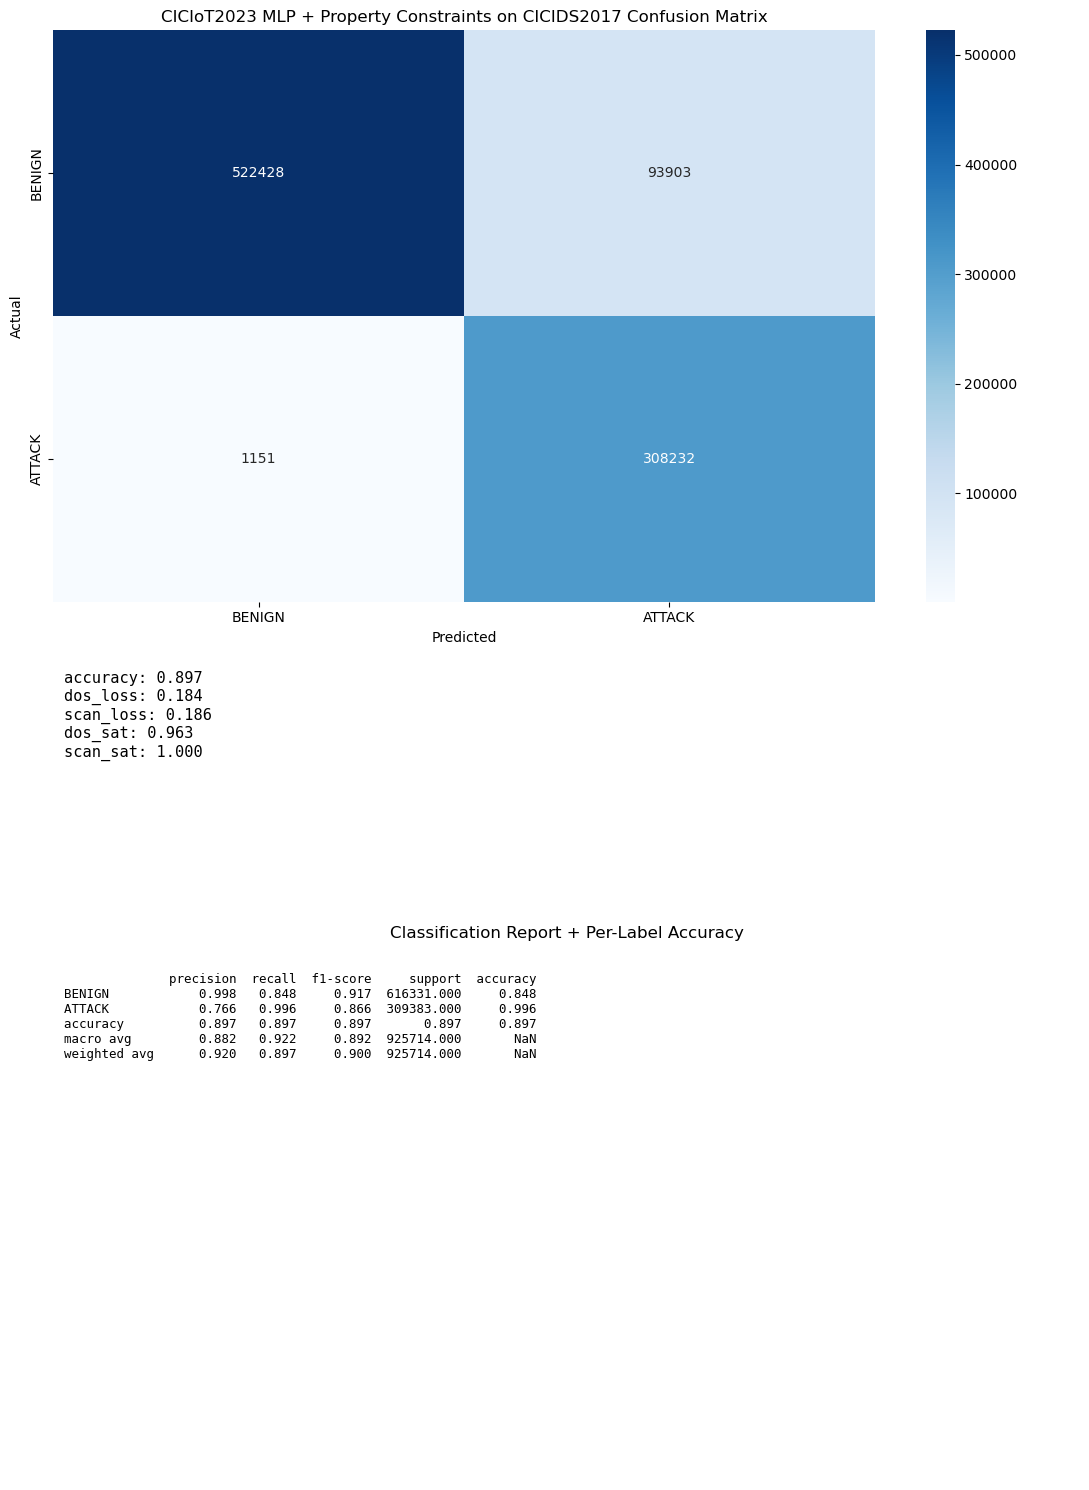

In [22]:
plot_eval_summary(
    metrics,
    report_df,
    cm,
    labels,
    model_name=f"{dataset_name} MLP + Property Constraints on {cross_eval_dataset_name}",
)